In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [3]:
TRAIN_DIR = "../dataset/PlantVillage_5Class/train"
VAL_DIR = "../dataset/PlantVillage_5Class/val"

In [4]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

Found 4268 files belonging to 5 classes.
Found 1068 files belonging to 5 classes.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [6]:
base_model = MobileNetV3Small(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [7]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    len(class_names),
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

In [8]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 1,088,117 (4.15 MB)

 Trainable params: 148,997 (582.02 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

training_time = time.time() - start_time

print("Training Time:", training_time)

Epoch 1/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 33s 199ms/step - accuracy: 0.9124 - loss: 0.2574 - val_accuracy: 0.9878 - val_loss: 0.0485
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 172ms/step - accuracy: 0.9813 - loss: 0.0621 - val_accuracy: 0.9906 - val_loss: 0.0263
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.9866 - loss: 0.0402 - val_accuracy: 0.9897 - val_loss: 0.0264
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 16s 123ms/step - accuracy: 0.9932 - loss: 0.0261 - val_accuracy: 0.9934 - val_loss: 0.0193
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.9923 - loss: 0.0237 - val_accuracy: 0.9934 - val_loss: 0.0231
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.9939 - loss: 0.0179 - val_accuracy: 0.9972 - val_loss: 0.0116
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 19s 145ms/step - accuracy: 0.9960 - loss: 0.0146 - val_accuracy: 0.9925 - val_loss: 0.0217
Epoch 8/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 21s 159ms/step - accuracy: 0.9960 - loss: 0

In [10]:
loss, accuracy = model.evaluate(val_ds)

print("Accuracy:", accuracy)
print("Loss:", loss)
print("Training Time:", training_time)

34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.2491 - loss: 2.3110
Accuracy: 0.2490636706352234
Loss: 2.3109545707702637


NameError: name 'training_time' is not defined

34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step


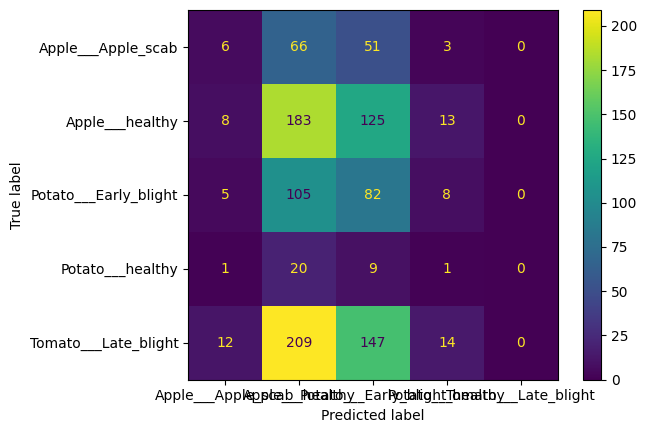

In [12]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

y_true = np.concatenate(
    [y for x, y in val_ds],
    axis=0
)

predictions = model.predict(val_ds)

y_pred = np.argmax(
    predictions,
    axis=1
)

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.show()

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# go to project root
base_dir = os.path.dirname(os.getcwd())
save_dir = os.path.join(base_dir, "results")
os.makedirs(save_dir, exist_ok=True)

# predictions
y_true = np.concatenate([y for _, y in val_ds], axis=0)
y_true = np.concatenate([y for _, y in val_ds], axis=0)

predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

# confusion matrix
cm = confusion_matrix(y_true, y_pred)

# plot
fig, ax = plt.subplots(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)

# save
fig.savefig(
    os.path.join(save_dir, "mobilenetv3_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.close()

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step


In [ ]:
plt.savefig("results/mobilenetv3_confusion_matrix.png", dpi=300, bbox_inches="tight")

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

y_true_bin = label_binarize(
    y_true,
    classes=range(len(class_names))
)

mAP = average_precision_score(
    y_true_bin,
    predictions,
    average="macro"
)

print("mAP:", mAP)

mAP: 0.21494625633773726


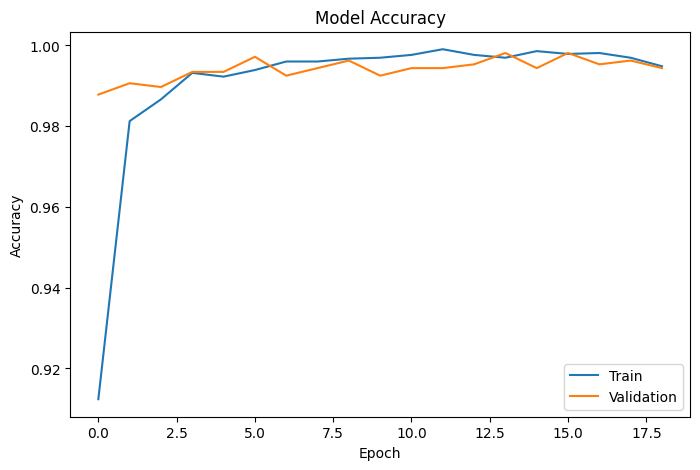

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.savefig("../results/model_accuracy.png")
plt.show()

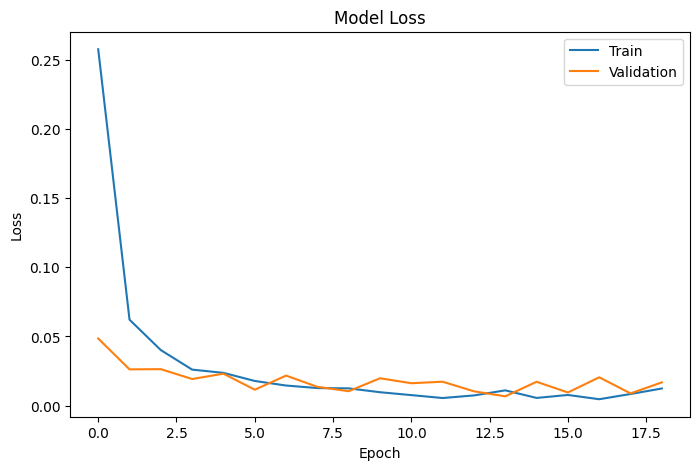

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.savefig("../results/model_loss.png")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step


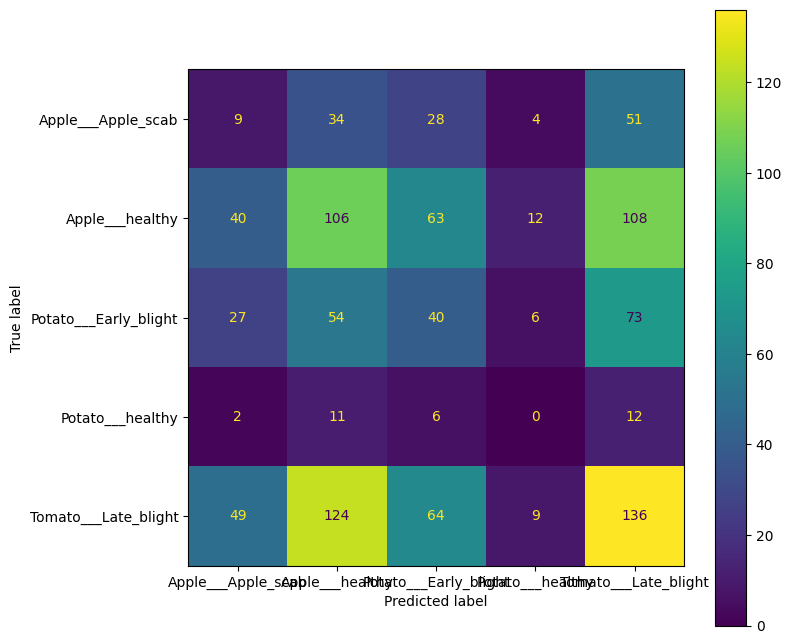

In [ ]:
y_true = np.concatenate(
    [y for x, y in val_ds],
    axis=0
)

predictions = model.predict(val_ds)

y_pred = np.argmax(
    predictions,
    axis=1
)

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax)


plt.show()

In [ ]:
import os

base_dir = os.path.dirname(os.getcwd())  # go one level up from models
save_dir = os.path.join(base_dir, "results")

os.makedirs(save_dir, exist_ok=True)

fig.savefig(
    os.path.join(save_dir, "mobilenetv3_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

In [ ]:
y_true_bin = label_binarize(
    y_true,
    classes=range(len(class_names))
)

mAP = average_precision_score(
    y_true_bin,
    predictions,
    average="macro"
)

print("mAP:", mAP)

mAP: 0.20254216144338608


In [ ]:
model.save("../models/mobilenetv3.keras")

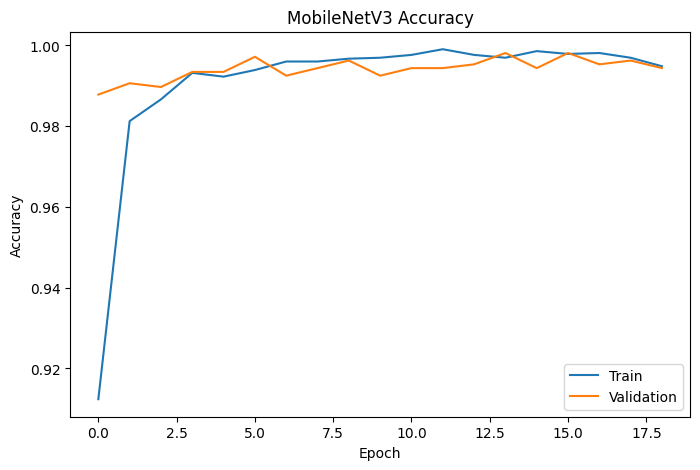

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('MobileNetV3 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

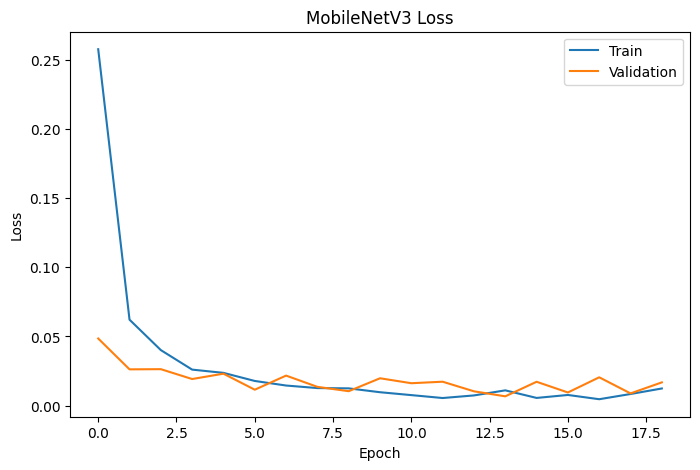

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('MobileNetV3 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

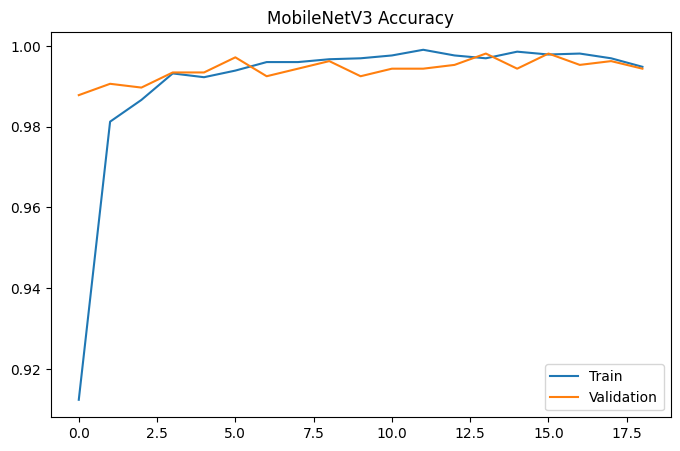

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('MobileNetV3 Accuracy')
plt.legend(['Train','Validation'])

plt.savefig("../results/mobilenet_accuracy.png")
plt.show()

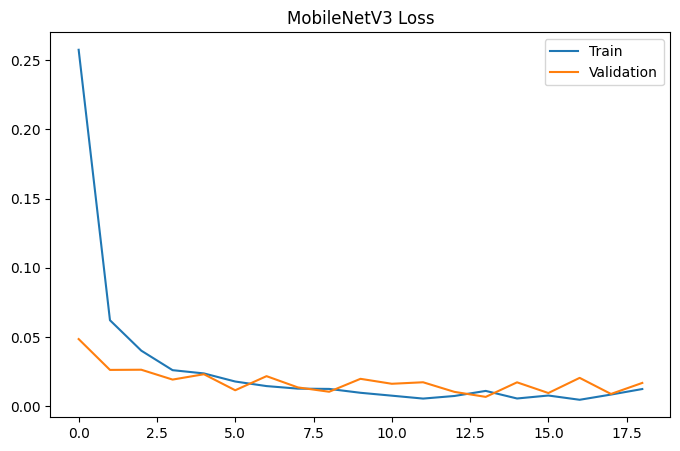

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('MobileNetV3 Loss')
plt.legend(['Train','Validation'])

plt.savefig("../results/mobilenet_loss.png")
plt.show()

In [ ]:
pd.DataFrame(history.history).to_csv(
    "../results/mobilenetv3_history.csv",
    index=False
)